In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
sns.set_theme(style="darkgrid")
%matplotlib inline

In [3]:
df_movies = pd.read_csv('movies.csv')
df_ratings = pd.read_csv('ratings.csv')

In [4]:
df = pd.merge(df_movies, df_ratings, on='movieId')

In [5]:
df.dropna(inplace=True)
df['movieId'] = df['movieId'].astype(str)

In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movieId    105339 non-null  object 
 1   title      105339 non-null  object 
 2   genres     105339 non-null  object 
 3   userId     105339 non-null  int64  
 4   rating     105339 non-null  float64
 5   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 4.8+ MB


movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [7]:
print("Unique users:", df['userId'].nunique())
print("Unique movies:", df['movieId'].nunique())
print("Unique genres:", df['genres'].nunique())

Unique users: 668
Unique movies: 10325
Unique genres: 938


Ratings Distribution

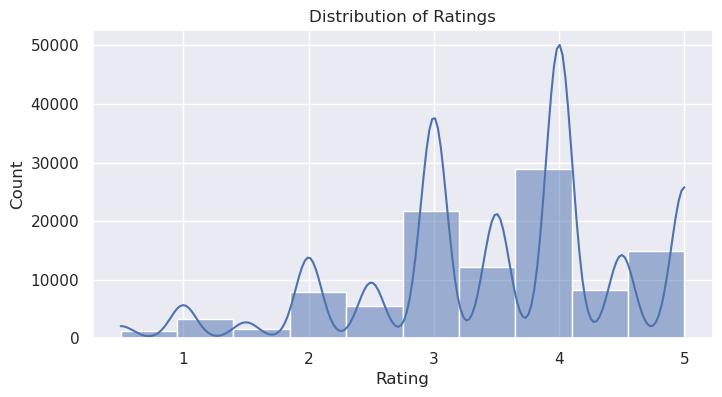

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Most Rated Movies

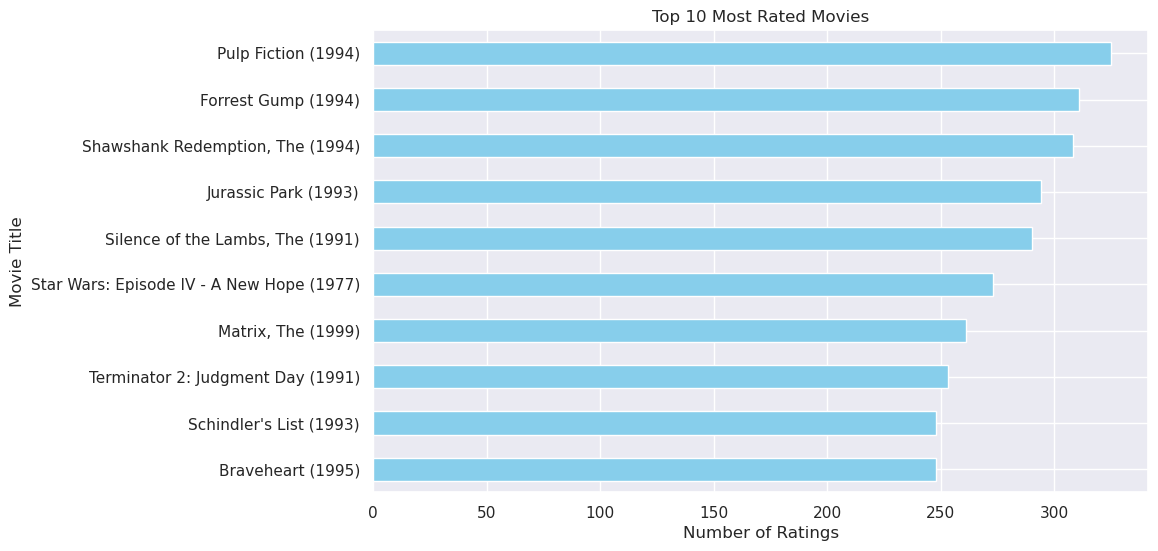

In [9]:
most_rated = df['title'].value_counts().head(10)
most_rated.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.gca().invert_yaxis()
plt.show()

Top Average Rated Movies

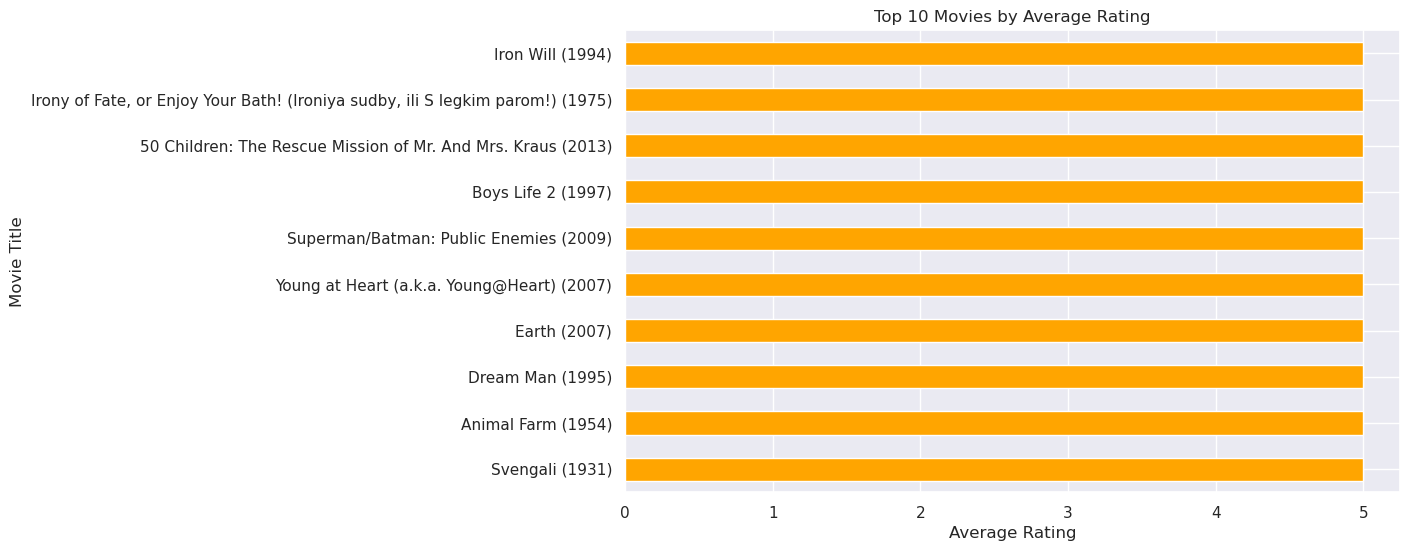

In [10]:
average_ratings = df.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)
average_ratings.plot(kind='barh', figsize=(10, 6), color='orange')
plt.title("Top 10 Movies by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.gca().invert_yaxis()
plt.show()

Ratings Over Time

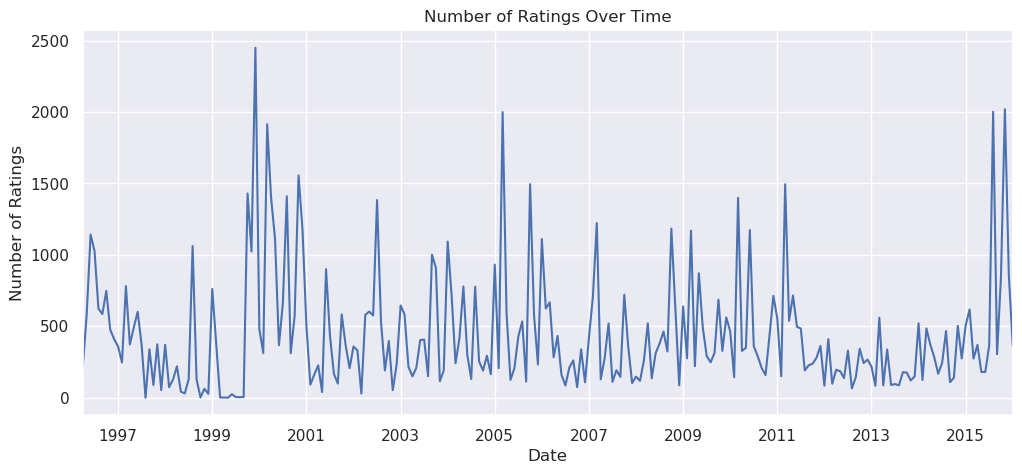

In [11]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')  # Convert timestamp to datetime
df.set_index('datetime')['rating'].resample('ME').count().plot(figsize=(12, 5))
plt.title("Number of Ratings Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Ratings")
plt.show()

Genre Popularity

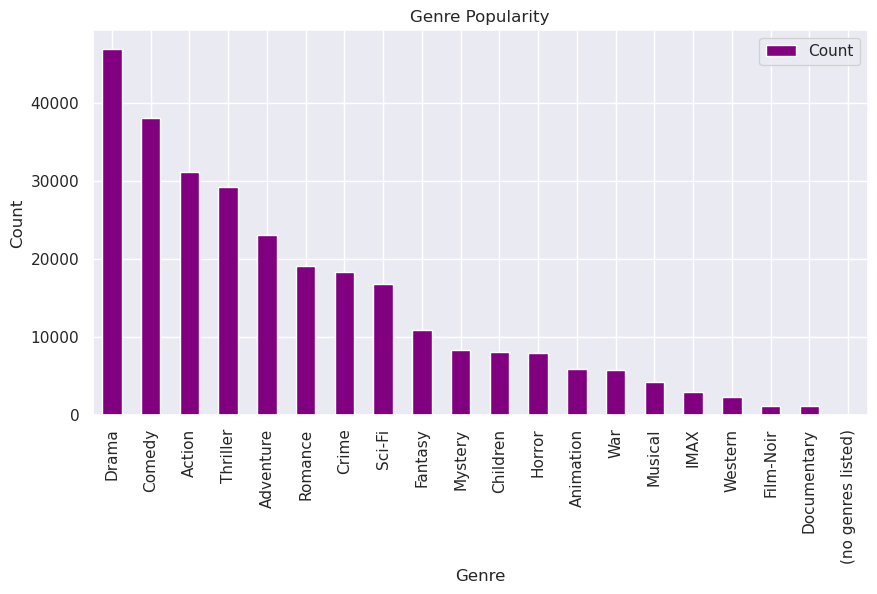

In [12]:
all_genres = df['genres'].str.split('|').sum()
genre_count = Counter(all_genres)

genre_df = pd.DataFrame(genre_count.items(), columns=["Genre", "Count"])
genre_df.sort_values(by="Count", ascending=False).plot(kind='bar', x='Genre', y='Count', figsize=(10, 5), color='purple')
plt.title("Genre Popularity")
plt.ylabel("Count")
plt.show()